In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator
import option_formulas

## Simulation of risk factors

In [2]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,50)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)


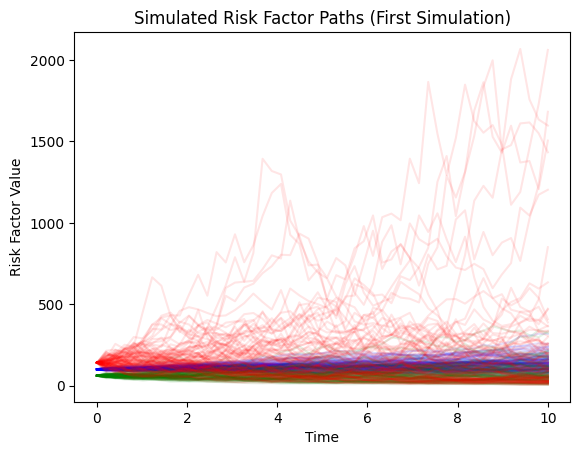

In [3]:
plt.plot(time_steps, paths[:100, :, 0].numpy().T, color='blue', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 1].numpy().T, color='green', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 2].numpy().T, color='red', alpha=0.1)
plt.title("Simulated Risk Factor Paths (First Simulation)")
plt.xlabel("Time")
plt.ylabel("Risk Factor Value")
plt.show()

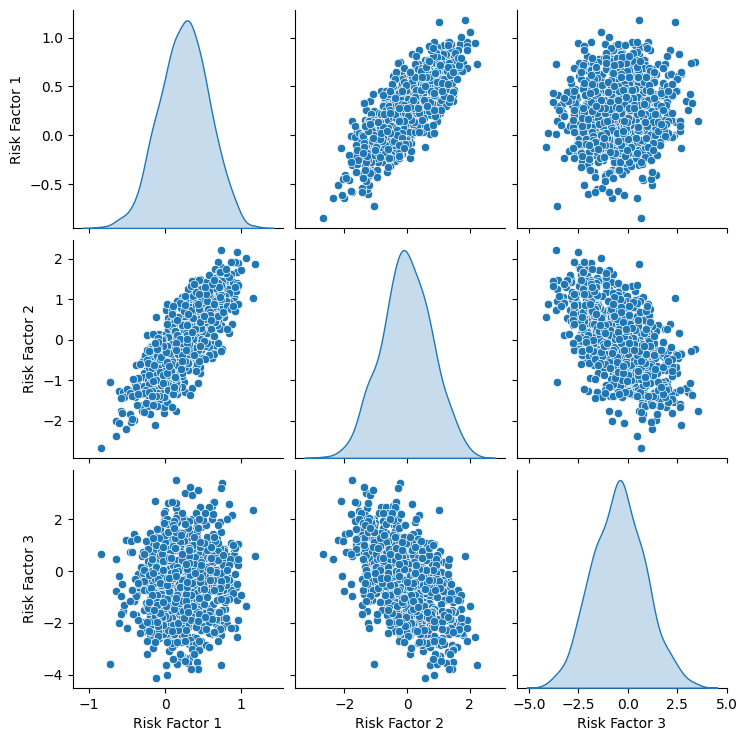

In [4]:
sns.pairplot(
    pd.DataFrame(np.log(paths[:,-1,:].numpy()/paths[:,0,:].numpy()), columns=[f"Risk Factor {i+1}" for i in range(num_risk_factors)]),
    diag_kind="kde")

### Test correlation and volatilities with odd time steps

In [5]:
time_steps = [0.0, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 30.0]

corr_matrix = [[1.0, 0.80, 0.10],
               [0.80, 1.0, -0.5],
                [0.10, -0.5, 1.0]]

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=30000)

for i in range(len(time_steps)-1):

    returns = np.log(paths[:,i+1,:].numpy()/paths[:,i,:].numpy())

    print("Volatilities at time step [", time_steps[i], "-", time_steps[i+1], "]:", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step [", time_steps[i], "-", time_steps[i+1], "]:")
    print(np.corrcoef(returns.T))
    



Volatilities at time step [ 0.0 - 0.5 ]: [0.09954348 0.24869985 0.3976728 ]
Correl matrix at time step [ 0.0 - 0.5 ]:
[[ 1.          0.79973904  0.10179578]
 [ 0.79973904  1.         -0.49864343]
 [ 0.10179578 -0.49864343  1.        ]]
Volatilities at time step [ 0.5 - 1.0 ]: [0.09984665 0.25097814 0.40026113]
Correl matrix at time step [ 0.5 - 1.0 ]:
[[ 1.          0.80094932  0.09312246]
 [ 0.80094932  1.         -0.50478213]
 [ 0.09312246 -0.50478213  1.        ]]
Volatilities at time step [ 1.0 - 2.5 ]: [0.10007116 0.24857073 0.39872652]
Correl matrix at time step [ 1.0 - 2.5 ]:
[[ 1.          0.79929862  0.10935346]
 [ 0.79929862  1.         -0.49291789]
 [ 0.10935346 -0.49291789  1.        ]]
Volatilities at time step [ 2.5 - 5.0 ]: [0.1006269  0.25175258 0.40106445]
Correl matrix at time step [ 2.5 - 5.0 ]:
[[ 1.          0.80154119  0.09806089]
 [ 0.80154119  1.         -0.49943234]
 [ 0.09806089 -0.49943234  1.        ]]
Volatilities at time step [ 5.0 - 7.5 ]: [0.09995219 0.2

### Simulate brownian bridge

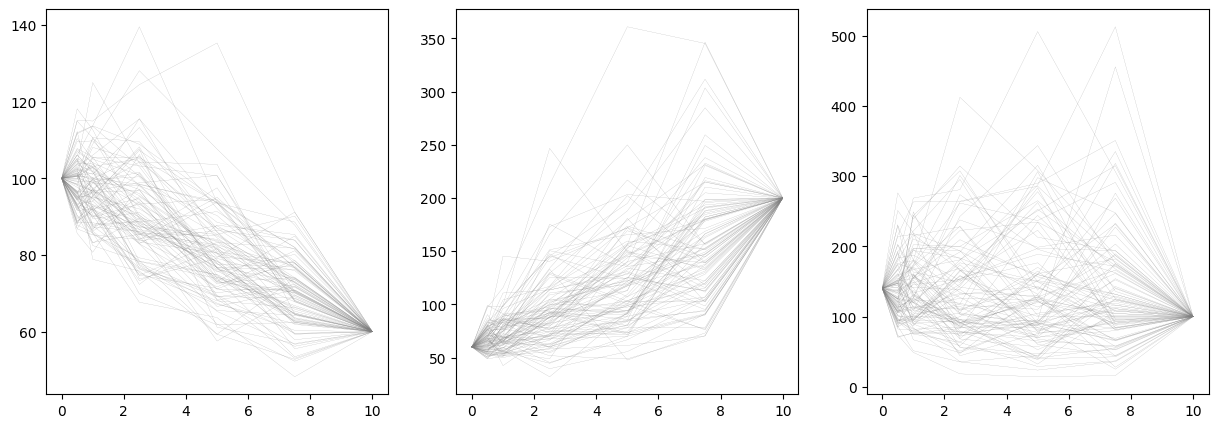

In [6]:
spot_t = [60,200,100]

time_index = 6

paths_bridge = simulator.simulate_paths_with_bridge(num_sims = 300000,
        pivot_step_idx = 6,
        spot_at_pivot= spot_t)

f, ax = plt.subplots(1,3, figsize=(15,5))


ax[0].plot(time_steps[0:time_index+1], paths_bridge[:100,:time_index+1,0].T.detach() ,linewidth = 0.1, color = 'grey');
ax[1].plot(time_steps[0:time_index+1], paths_bridge[:100,:time_index+1,1].T.detach(), linewidth = 0.1, color = 'grey');
ax[2].plot(time_steps[0:time_index+1], paths_bridge[:100,:time_index+1,2].T.detach(), linewidth = 0.1, color = 'grey');



### Test simulation brownian bridge

In [7]:
for i in range(6):

    returns = np.log(paths_bridge[:,i+1,:].numpy()/paths_bridge[:,i,:].numpy())

    print("Volatilities at time step [", time_steps[i], "-", time_steps[i+1], "]:", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step [", time_steps[i], "-", time_steps[i+1], "]:")
    print(np.corrcoef(returns.T))
    

Volatilities at time step [ 0.0 - 0.5 ]: [0.09735811 0.24355345 0.39024731]
Correl matrix at time step [ 0.0 - 0.5 ]:
[[ 1.          0.79937514  0.10038974]
 [ 0.79937514  1.         -0.50053649]
 [ 0.10038974 -0.50053649  1.        ]]
Volatilities at time step [ 0.5 - 1.0 ]: [0.09734641 0.24334567 0.38982498]
Correl matrix at time step [ 0.5 - 1.0 ]:
[[ 1.          0.79957322  0.10129651]
 [ 0.79957322  1.         -0.49947459]
 [ 0.10129651 -0.49947459  1.        ]]
Volatilities at time step [ 1.0 - 2.5 ]: [0.09215684 0.23028536 0.36909502]
Correl matrix at time step [ 1.0 - 2.5 ]:
[[ 1.          0.79931727  0.1008635 ]
 [ 0.79931727  1.         -0.50025469]
 [ 0.1008635  -0.50025469  1.        ]]
Volatilities at time step [ 2.5 - 5.0 ]: [0.08643416 0.2165087  0.34718875]
Correl matrix at time step [ 2.5 - 5.0 ]:
[[ 1.          0.79905138  0.09812141]
 [ 0.79905138  1.         -0.50290382]
 [ 0.09812141 -0.50290382  1.        ]]
Volatilities at time step [ 5.0 - 7.5 ]: [0.08666171 0.2

### Test closed form formula

In [8]:

init_time_array = torch.linspace(0,10,41)

initial_spot_values = torch.tensor([100.0, 60.0, 140.0])
drift_array = torch.tensor([0.03, 0.03, 0.03])
volatility_array = torch.tensor([0.10, 0.25, 0.40])
correl_matrix = torch.tensor([
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
])

price_history = torch.zeros((num_risk_factors, len(init_time_array)))

price_history[:,0] = initial_spot_values


option_formulas.BasketGeomAsian(init_time_array, 0, 0.01, 3,
                     volatility_array, correl_matrix, price_history, True)

tensor(0.0496)

In [10]:
N = torch.distributions.Normal(loc=0.0, scale=1.0).cdf

def Black(Forward: torch.FloatTensor, Strike: torch.FloatTensor, 
          TTM: torch.FloatTensor, rate: torch.FloatTensor, Vol: torch.FloatTensor,
          IsCall: bool,  device=None, dtype=torch.float64,) -> torch.FloatTensor  :

  '''
  Inputs:
  -------
    Forward (float): Forward value
    Strike (float): strike price
    TTM (float): time to maturity in years
    rate (float): risk free rate
    Vol (float): volatility
    IsCall (bool): True if call option, False if put option
  Outputs:
  --------
    Option premium (float)
  '''

  if TTM >0:

    d1 = (torch.log(Forward/Strike) + (Vol*Vol/2)*TTM)/(Vol*torch.sqrt(TTM))
    d2 = (torch.log(Forward/Strike) + (- Vol*Vol/2)*TTM)/(Vol*torch.sqrt(TTM))

    if IsCall:

      return (Forward*N(d1)-Strike*N(d2))*torch.exp(-rate*TTM)

    else:

      return (-Forward*N(-d1)+Strike*N(-d2))*torch.exp(-rate*TTM)

  else:

    if IsCall:

      return torch.maximum(Forward-Strike,0)

    else:

      return torch.maximum(-Forward+Strike,0)
    














def BasketGeomAsianVec(
    init_time_array,
    value_date_index,
    risk_free_rate,
    num_assets,
    assets_vol,
    assets_correl,
    price_history,
    IsCall
):
    """
    price_history: shape (num_sims, num_time_steps, num_assets)
    returns: shape (num_sims,)
    """

    num_asian_dates = len(init_time_array)

    pending_times_array = (
        init_time_array[value_date_index + 1:]
        - init_time_array[value_date_index]
    )

    mu = (
        torch.sum(risk_free_rate - 0.5 * assets_vol * assets_vol)
        * torch.sum(pending_times_array)
        / (num_assets * (num_asian_dates - 1))
    )

    diag_vol = torch.diag(assets_vol.reshape(-1))
    cov_matrix = diag_vol @ assets_correl @ diag_vol

    xx, yy = torch.meshgrid(
        pending_times_array,
        pending_times_array,
        indexing="ij"
    )
    z = torch.minimum(xx, yy)

    V = (
        torch.sum(cov_matrix)
        * torch.sum(z)
        / (num_assets * num_assets * (num_asian_dates - 1) ** 2)
    )

    # Initial fixing, shape (num_sims, 1, num_assets)
    S0 = price_history[:, 0:1, :]

    # Historical fixings from index 1 through value_date_index inclusive
    hist_ratio = price_history[:, 1:value_date_index + 1, :] / S0

    # Product over time and assets, preserving simulation dimension
    hist_prod = torch.prod(hist_ratio, dim=(1, 2))

    Forward = hist_prod ** (1.0 / (num_assets * (num_asian_dates - 1)))

    # Current/value-date fixing ratio, shape (num_sims, num_assets)
    current_ratio = price_history[:, value_date_index, :] / price_history[:, 0, :]

    current_prod = torch.prod(current_ratio, dim=1)

    Forward *= current_prod ** (
        (num_asian_dates - value_date_index - 1)
        / (num_assets * (num_asian_dates - 1))
    )

    Forward *= torch.exp(mu + 0.5 * V)

    remaining_maturity = (
        init_time_array[-1] - init_time_array[value_date_index]
    )

    vol_eff = torch.sqrt(V / remaining_maturity)

    return Black(
        Forward,
        torch.ones_like(Forward),
        remaining_maturity,
        risk_free_rate,
        vol_eff,
        IsCall
    )

In [ ]:

init_time_array = torch.linspace(0,10,41)

initial_spot_values = torch.tensor([100.0, 60.0, 140.0])
drift_array = torch.tensor([0.03, 0.03, 0.03])
volatility_array = torch.tensor([0.10, 0.25, 0.40])
correl_matrix = torch.tensor([
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
])

price_history = torch.zeros((num_risk_factors, len(init_time_array)))

price_history[:,0] = initial_spot_values


option_formulas.BasketGeomAsian(init_time_array, 0, 0.01, 3,
                     volatility_array, correl_matrix, price_history, True)

In [11]:
paths.shape

torch.Size([30000, 9, 3])